# All simulations used in our thesis

Spørgsmål og undren her: (skal slettes når der fås styr på dette)

Afkast: 
- Indtil videre i vores simulationer har vi brugt månedligt afkast $R_{m} = 0.10$, hvilket svarer til årligt afkast $R_{y} = (1 + 0.10)^{12} - 1 \approx 2.138 = 213.8\%$ om året. Dette er meget urealistisk. Skal dette passe med hvad der er normalt e.g. 7\% om året ville det månedlige afkast være $R_m = (1+0.07)^{1/12} - 1 \approx 0,005654 = 0.56\%$ om måneden. 
- Problemet er, at hvis vi bruger denne rente, så vil vi ikke kunne frembringe nogen bobler i vores simulationer. Afkastet bliver alt for lavt til at boblen kan gro hurtigt nok. Det vil kræve en enorm lang tidshorisont.

### In this notebook all simulations are displayed

In [50]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib
sys.path.append(os.path.abspath(".."))

# Import functions
from functions import simulation_master_v2

# Reload functions
importlib.reload(simulation_master_v2)


<module 'functions.simulation_master_v2' from '/Users/emilrand/Desktop/ku/bachelor/6. semester/ba/ba_repo/functions/simulation_master_v2.py'>

### Equations used for simulations

The equations for our simulations stem from the theoretical section in our thesis, and are given by: 

\begin{align*}
D_{t+1} &= \mu + \rho D_t + \varepsilon_{D_{t+1}}, \quad \varepsilon_{D_t} \overset{i.i.d}{\sim} N(\mu_D, \sigma_D^2) \tag{Dividend process} \\
    P_t^f &= \frac{\rho}{1+R-\rho}D_t + \frac{(\mu+\mu_D)(1+R)}{R(1+R-\rho)} \tag{Price fundamentals} \\
    B_{t+1} &= (1+R)B_t + \varepsilon_{B_{t+1}}, \quad \varepsilon_{B_t} \overset{i.i.d}{\sim} N(\mu_B, \sigma_B^2) \tag{Bubble component} \\
    P_t &= P_t^f + B_t \tag{Stock price}
\end{align*}



### AR(1) with random walk in the dividends

In [95]:
D, Pf, B, P = simulation_master_v2.simulate_price_with_bubbles(
    
    # Sample size
    T = 3_000,

    # Parameters for discount rate and drift scaling
    R = 0.005654,
    d = 1.0,
    eta = 1.0,
    
    # Dividend process
    rho = 1.0,
    mu_D = 0.0,
    sigma_D = 0.5,

    # Bubble process
    mu_B = 0.0,
    sigma_B = 0.5, 
    decay = 0.7,

    # Multiple bubbles
    include_bubble = True,
    t_start1 = 75,
    t_end1 = 1_500,
    B0_1 = 0.0,
    t_start2 = None,
    t_end2 = None,
    B0_2 = 0.0,
    
    # Initial values
    D0 = 10.0,
    B0 = 10.0,

    # Seed
    seed = 42,

)

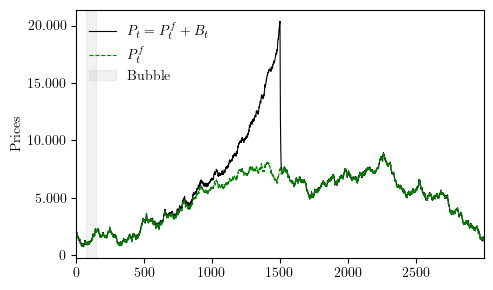

In [96]:
# plotting AR(1) with random walk

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P.index, P.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
# plt.plot(D.index, D.values, color='orange', linewidth=0.8, ls='-', label=r'$D_t$')
plt.plot(Pf.index, Pf.values, color='green', linewidth=0.8, ls='--', label=r'$P_t^f$')
# plt.plot(B.index, B.values, color='red', linewidth=0.8, ls='-', label=r'$B_t$')
plt.ylabel(r'Prices')

# shading for bubble
plt.axvspan(75, 150, color='grey', alpha=0.1, label='Bubble')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P.index.min(), P.index.max())

# save
# plt.savefig('name.pdf') # <- remeber to save plot here by uncommenting and choosing a path and name
plt.show()